In [2]:
import os
import sys

nest_root = "/home/camilojd/AA_Work/Sussex/nest_installations/nest_39"
site_packages = f"{nest_root}/lib/python3.11/site-packages"
bin_dir = f"{nest_root}/bin"

os.environ["PYTHONPATH"] = site_packages + (f":{os.environ['PYTHONPATH']}" if os.environ.get("PYTHONPATH") else "")
os.environ["PATH"] = bin_dir + (f":{os.environ['PATH']}" if os.environ.get("PATH") else "")

if site_packages not in sys.path:
    sys.path.insert(0, site_packages)
    
import nest
import numpy as np
import matplotlib.pyplot as plt


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Nov 18 2025 10:02:43

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [3]:
def encode_input_to_wave(initial_time, end_time, sampling_rate):
    spike_times = np.arange(initial_time, end_time, sampling_rate)
    return spike_times

class DataloaderXOR:
    def __init__(self, n_in, epochs, iterations_steps, resolution):
        self.n_in = n_in
        self.epochs = epochs
        self.iteration_steps = iterations_steps
        self.resolution = resolution

        self.sequences = ["00", "01", "10", "11"]
        self.sequence_weights = [0.5, 0.2, 0.2, 0.1]

        self.map_sequence_to_freq = {
            "0": 25,
            "1": 51
        }

        self.data, self.targets, self.pattern_history = self.generate_data()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, epoch):
        return self.data[epoch], self.targets[epoch]

    def generate_data(self):
        data = []
        targets = []
        pattern_history = []
        for epoch in range(self.epochs):
            pattern_sequence = np.random.choice(
                self.sequences, 
                p=self.sequence_weights)

            first_input = encode_input_to_wave(
                initial_time=(epoch * self.iteration_steps * self.resolution),
                end_time=(epoch+1) * self.iteration_steps * self.resolution,
                sampling_rate=self.map_sequence_to_freq[pattern_sequence[0]]
            )
            second_input = encode_input_to_wave(
                initial_time=(epoch * self.iteration_steps * self.resolution),
                end_time=(epoch+1) * self.iteration_steps * self.resolution,
                sampling_rate=self.map_sequence_to_freq[pattern_sequence[1]]
            )
            
            if (pattern_sequence == "01") or (pattern_sequence == "10"):
                target = 1
            else:
                target = 0
                
            data.append([first_input, second_input])
            targets.append(target)
            pattern_history.append({
                "pattern": pattern_sequence,
            })
        return data, targets, pattern_history

In [4]:
params_setup = {
    "resolution": 0.1,
}

nest.ResetKernel()
nest.set(**params_setup)
nest.set_verbosity("M_FATAL")


Jun 01 20:25:56 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.1 ms.


In [5]:
# Training parameters
epochs = 100
iteration_steps = 600

# Network parameters
n_in = 2  # number of input neurons
n_rec = 2  # number of recurrent neuronsdata
n_out = 2  # number of readout neurons

group_size = 1

steps = {
    "learning_window": 10,
    "offset_gen": 1,  # offset since generator signals start from time step 1
    "delay_in_rec": 1,  # connection delay between input and recurrent neurons
    "extension_sim": 1, # extra time step to close right-open simulation time interval in Simulate()
    "sequence": iteration_steps
}

steps["delays"] = steps["delay_in_rec"]  # time steps of delays
steps["total_offset"] = steps["offset_gen"] + steps["delays"]  # time steps of total offset

duration = {key: value * params_setup["resolution"] for key, value in steps.items()}

In [6]:
mm_rec = nest.Create("multimeter", params={
    "interval": params_setup["resolution"], # interval between two recorded time points
    "record_from": ["V_m", "surrogate_gradient", "learning_signal"], # dynamic variables to record
    "start": duration["total_offset"],  # start time of recording
})
mm_out = nest.Create("multimeter", params={
    "interval": params_setup["resolution"],
    "record_from": ["V_m", "readout_signal", "target_signal", "error_signal"],
    "start": duration["total_offset"],
})
sr_in = nest.Create("spike_recorder", params={
    "start": duration["offset_gen"]
})
sr_rec = nest.Create("spike_recorder", params={
    "start": duration["offset_gen"]
})
wr = nest.Create("weight_recorder", params={
    "start": duration["total_offset"]
})

recorders = {
    "mm_rec": mm_rec,
    "mm_out": mm_out,
    "sr_in": sr_in,
    "sr_rec": sr_rec,
    "wr": wr
}

In [7]:
params_common_syn_eprop = {
    "optimizer": {
        "type": "gradient_descent",  # algorithm to optimize the weights
        "batch_size": 1,
        "optimize_each_step": False,  # call optimizer every time step (True) or once per spike (False); both
        # yield same results for gradient descent, False offers speed-up
        "Wmin": -100.0,  # pA, minimal limit of the synaptic weights
        "Wmax": 100.0,  # pA, maximal limit of the synaptic weights
    },
    "weight_recorder": wr,
}
nest.SetDefaults("eprop_synapse", params_common_syn_eprop)

In [8]:
class Network:
    def __init__(self, n_in, n_rec, n_out, delay, recorders):
        """
        Create network
            n_in (int)
            n_rec (int)
            n_out (int)
            recorders (dict): could contain keys sr_in, sr_rec, mm_rec, mm_out
        """
        # Network parameters
        self.n_in = n_in
        self.n_rec = n_rec
        self.n_out = n_out
        self.delay = delay # duration["step"]

        # Recorders
        self.recorders = recorders

        # Setup, creation and connection
        self.setup()
        self.create()
        self.connect()

        self.results_dict = {
            "error": [],
            "loss": [],
            "iteration": [],
            "label": [],
        }

    def setup(self):
        # Setup connection parameters
        self.params_conn_one_to_one = {
            "rule": "one_to_one"
        }
        self.params_conn_all_to_all = {
            "rule": "all_to_all", "allow_autapses": False
        }
        
        # Setup synaptic parameters
        self.params_syn_static = {
            "synapse_model": "static_synapse",
            "delay": self.delay,
        }
        self.params_syn_eprop = {
            "synapse_model": "eprop_synapse",
            "delay": self.delay,  # ms, dendritic delay
        }
        self.params_syn_feedback = {
            "synapse_model": "eprop_learning_signal_connection",
            "delay": self.delay
        }
        self.params_syn_learning_window = {
            "synapse_model": "rate_connection_delayed",
            "delay": self.delay,
            "receptor_type": 1,  # receptor type over which readout neuron receives learning window signal
        }
        self.params_syn_rate_target = {
            "synapse_model": "rate_connection_delayed",
            "delay": self.delay,
            "receptor_type": 2,  # receptor type over which readout neuron receives target signal
        }
    
    def create(self):
        """
        Network creation
        """
        # Spike input generator
        self.gen_spk_in = nest.Create("spike_generator", self.n_in)

        # Recurrent Network
        self.nrns_in = nest.Create("parrot_neuron", self.n_in)
        self.nrns_rec = nest.Create("eprop_iaf", self.n_rec)
        self.nrns_out = nest.Create("eprop_readout", self.n_out)

        # Output spike generators
        self.gen_rate_target = nest.Create("step_rate_generator", self.n_out)
        self.gen_learning_window = nest.Create("step_rate_generator")
        self.gen_spk_final_update = nest.Create("spike_generator", 1)

    def connect(self):
        self.connect_network()
        self.connect_recorders()
        
    def connect_network(self):
        """
        Connect network following connections on display
        """
        nest.Connect(
            self.gen_spk_in, 
            self.nrns_in, 
            self.params_conn_one_to_one, 
            self.params_syn_static)  # connection 1

        # Should this connections be sparse?? (2,3,4)
        
        nest.Connect(
            self.nrns_in, 
            self.nrns_rec,
            self.params_conn_all_to_all,
            self.params_syn_eprop)  # connection 2
        nest.Connect(
            self.nrns_rec, 
            self.nrns_rec,
            self.params_conn_all_to_all,
            self.params_syn_eprop)  # connection 3
        nest.Connect(
            self.nrns_rec, 
            self.nrns_out,
            self.params_conn_all_to_all,
            self.params_syn_eprop)  # connection 4
        
        nest.Connect(
            self.nrns_out, 
            self.nrns_rec, 
            self.params_conn_all_to_all, 
            self.params_syn_feedback)  # connection 5
        
        nest.Connect(
            self.gen_rate_target, 
            self.nrns_out, 
            self.params_conn_one_to_one, 
            self.params_syn_rate_target)  # connection 6
        nest.Connect(
            self.gen_learning_window, 
            self.nrns_out, 
            self.params_conn_all_to_all, 
            self.params_syn_learning_window)  # connection 7

        # Force final update to update all synapses 
        # it include all that have not being transmitted in the last update
        nest.Connect(
            self.gen_spk_final_update, 
            self.nrns_in + self.nrns_rec, 
            "all_to_all", {"weight": 1000.0})

    def connect_recorders(self):
        """
        Connect recorders
        """
        if self.recorders.get("sr_in"):
            nest.Connect(
                self.nrns_in, 
                self.recorders["sr_in"], 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("sr_rec"):
            nest.Connect(
                self.nrns_rec, 
                self.recorders["sr_rec"], 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("mm_rec"):
            nest.Connect(
                self.recorders["mm_rec"], 
                self.nrns_rec, 
                self.params_conn_all_to_all, 
                self.params_syn_static)
        if self.recorders.get("mm_out"):
            nest.Connect(
                self.recorders["mm_out"], 
                self.nrns_out, 
                self.params_conn_all_to_all, 
                self.params_syn_static)

    def evaluate(self, epoch, group_size, steps_sequence, steps_total_offset, steps_learning_window, resolution, phase_label):
        duration_sequence = steps_sequence * resolution
        duration_total_offset = steps_total_offset * resolution
        
        events_mm_out = self.recorders["mm_out"].get("events")
        
        readout_signal = events_mm_out["readout_signal"]
        target_signal = events_mm_out["target_signal"]
        senders = events_mm_out["senders"]
        times = np.around(events_mm_out["times"], 5) # Rounded since decimal errors on cond2

        cond1 = times > (epoch - 1) * group_size * duration_sequence + duration_total_offset
        cond2 = times <= epoch * group_size * duration_sequence + duration_total_offset
        idc = cond1 & cond2

        readout_signal = np.array([readout_signal[idc][senders[idc] == i] for i in set(senders)])
        target_signal = np.array([target_signal[idc][senders[idc] == i] for i in set(senders)])

        readout_signal = readout_signal.reshape((readout_signal.shape[0], 1, group_size, steps_sequence))
        target_signal = target_signal.reshape((target_signal.shape[0], 1, group_size, steps_sequence))

        readout_signal = readout_signal[:, :, :, -steps_learning_window :]
        target_signal = target_signal[:, :, :, -steps_learning_window :]

        loss = 0.5 * np.mean(np.sum((readout_signal - target_signal) ** 2, axis=3), axis=(0, 2))

        y_prediction = np.argmax(np.mean(readout_signal, axis=3), axis=0)
        y_target = np.argmax(np.mean(target_signal, axis=3), axis=0)
        accuracy = np.mean((y_target == y_prediction), axis=1)
        errors = 1.0 - accuracy

        self.results_dict["iteration"].append(epoch)
        self.results_dict["error"].extend(errors)
        self.results_dict["loss"].extend(loss)
        self.results_dict["label"].append(phase_label)

        

In [9]:
net = Network(n_in, n_rec, n_out, params_setup["resolution"], recorders)

In [10]:
data_loader = DataloaderXOR(
    n_in=n_in, 
    epochs=epochs, 
    iterations_steps=steps["sequence"], 
    resolution=params_setup["resolution"])

In [11]:
for epoch, (data, target) in enumerate(data_loader):
    print(epoch, data, target)
    one_hot_target = np.zeros(n_out)
    one_hot_target[target] = 1

    iteration_offset = epoch * group_size * duration["sequence"]
    
    params_gen_spk_in = [
        #{"spike_times": data[0]},
        #{"spike_times": data[1]},
        {"spike_times": data[0] + duration["total_offset"]},
        {"spike_times": data[1] + duration["total_offset"]},
    ]
    params_gen_rate_target = [
        {
            "amplitude_times": np.arange(
                0.0, 
                group_size * duration["sequence"], 
                duration["sequence"])
                + iteration_offset
                + duration["total_offset"],
            "amplitude_values": np.ones(1) if one_hot_target[i] else np.zeros(1)
        } for i in range(n_out)
    ]
    params_gen_learning_window = {
        "amplitude_times": np.hstack(
            [
                np.array([0.0, duration["sequence"] - duration["learning_window"]])
                + iteration_offset
                + group_element * duration["sequence"]
                + duration["total_offset"]
                for group_element in range(group_size)
            ]
        ),
        "amplitude_values": np.tile([0.0, 1.0], group_size)
    }
    
    nest.SetStatus(net.gen_spk_in, params_gen_spk_in)
    nest.SetStatus(net.gen_rate_target, params_gen_rate_target)
    nest.SetStatus(net.gen_learning_window, params_gen_learning_window)

    nest.Simulate(duration["total_offset"])
    nest.Simulate(duration["extension_sim"])

    print("params_gen_spk_in", params_gen_spk_in)
    print("params_gen_rate_target", params_gen_rate_target)
    print("params_gen_learning_window", params_gen_learning_window)
    if epoch > 0:
        net.evaluate(
            epoch=epoch, 
            group_size=group_size, 
            steps_sequence=steps["sequence"], 
            steps_total_offset=steps["total_offset"], 
            steps_learning_window=steps["learning_window"], 
            resolution=params_setup["resolution"], 
            phase_label="train")

    duration_sim = group_size * duration["sequence"] - duration["total_offset"] - duration["extension_sim"]
    nest.Simulate(duration_sim)
        

0 [array([ 0., 25., 50.]), array([ 0., 25., 50.])] 0
params_gen_spk_in [{'spike_times': array([ 0.2, 25.2, 50.2])}, {'spike_times': array([ 0.2, 25.2, 50.2])}]
params_gen_rate_target [{'amplitude_times': array([0.2]), 'amplitude_values': array([1.])}, {'amplitude_times': array([0.2]), 'amplitude_values': array([0.])}]
params_gen_learning_window {'amplitude_times': array([ 0.2, 59.2]), 'amplitude_values': array([0., 1.])}
1 [array([ 60., 111.]), array([ 60.,  85., 110.])] 1
params_gen_spk_in [{'spike_times': array([ 60.2, 111.2])}, {'spike_times': array([ 60.2,  85.2, 110.2])}]
params_gen_rate_target [{'amplitude_times': array([60.2]), 'amplitude_values': array([0.])}, {'amplitude_times': array([60.2]), 'amplitude_values': array([1.])}]
params_gen_learning_window {'amplitude_times': array([ 60.2, 119.2]), 'amplitude_values': array([0., 1.])}
2 [array([120., 171.]), array([120., 171.])] 0
params_gen_spk_in [{'spike_times': array([120.2, 171.2])}, {'spike_times': array([120.2, 171.2])}]
p

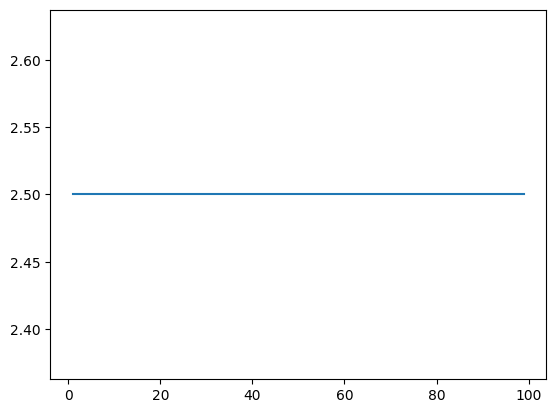

In [12]:
plt.plot(net.results_dict["iteration"], net.results_dict["loss"])

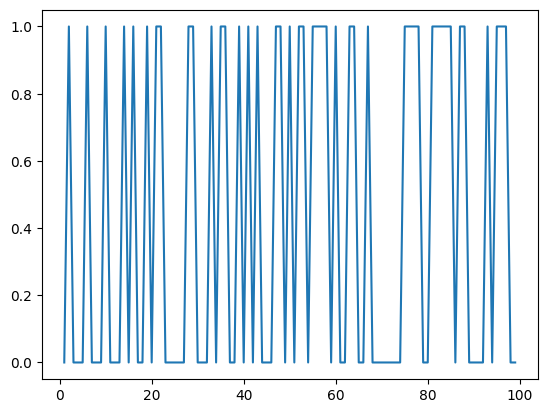

In [13]:
plt.plot(net.results_dict["iteration"], net.results_dict["error"])

In [14]:
import pandas as pd

# Input
events_sr_in = recorders["sr_in"].get("events")
df_in = pd.DataFrame(events_sr_in)
df_in.set_index(["senders"], inplace=True)

# Recurrent
mm_rec_events = recorders["mm_rec"].get("events")
times_rec = mm_rec_events["times"]
Vms = mm_rec_events["V_m"]
surrogate_gradient = mm_rec_events["surrogate_gradient"]
learning_signal = mm_rec_events["learning_signal"]

sr_rec_events = recorders["sr_rec"].get("events")
ts_sr_rec = sr_rec_events["times"]

# Readout
mm_out_events = recorders["mm_out"].get("events")
ts_mm_out = mm_out_events["times"]
Vrs = mm_out_events["V_m"]
target_signal = mm_out_events["target_signal"]
error_signal = mm_out_events["error_signal"]

# Weights
events_wr = recorders["wr"].get("events")

nrns = {
    "in": net.nrns_in.tolist(),
    "rec": net.nrns_rec.tolist(),
    "out": net.nrns_out.tolist(),
}

df_wr = pd.DataFrame(events_wr)
df_wr.set_index(["senders", "targets"], inplace=True)

in_rec_idx = pd.MultiIndex.from_product([nrns["in"], nrns["rec"]])
rec_rec_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["rec"]])
rec_out_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["out"]])

df_in_rec = df_wr.loc[df_wr.index.intersection(in_rec_idx)]
df_rec_rec = df_wr.loc[df_wr.index.intersection(rec_rec_idx)]
df_rec_out = df_wr.loc[df_wr.index.intersection(rec_out_idx)]

In [15]:
def plot_weight_time_course(df, ax):
    for idx in df.index.unique():
        df_filt = df.loc[idx]#.sort_values(by="time_ms")
        ax.plot(df_filt["times"], df_filt["weights"], "--")

/tmp/ipykernel_88885/3670862113.py:23: UserWarning:No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
/tmp/ipykernel_88885/3670862113.py:31: UserWarning:No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


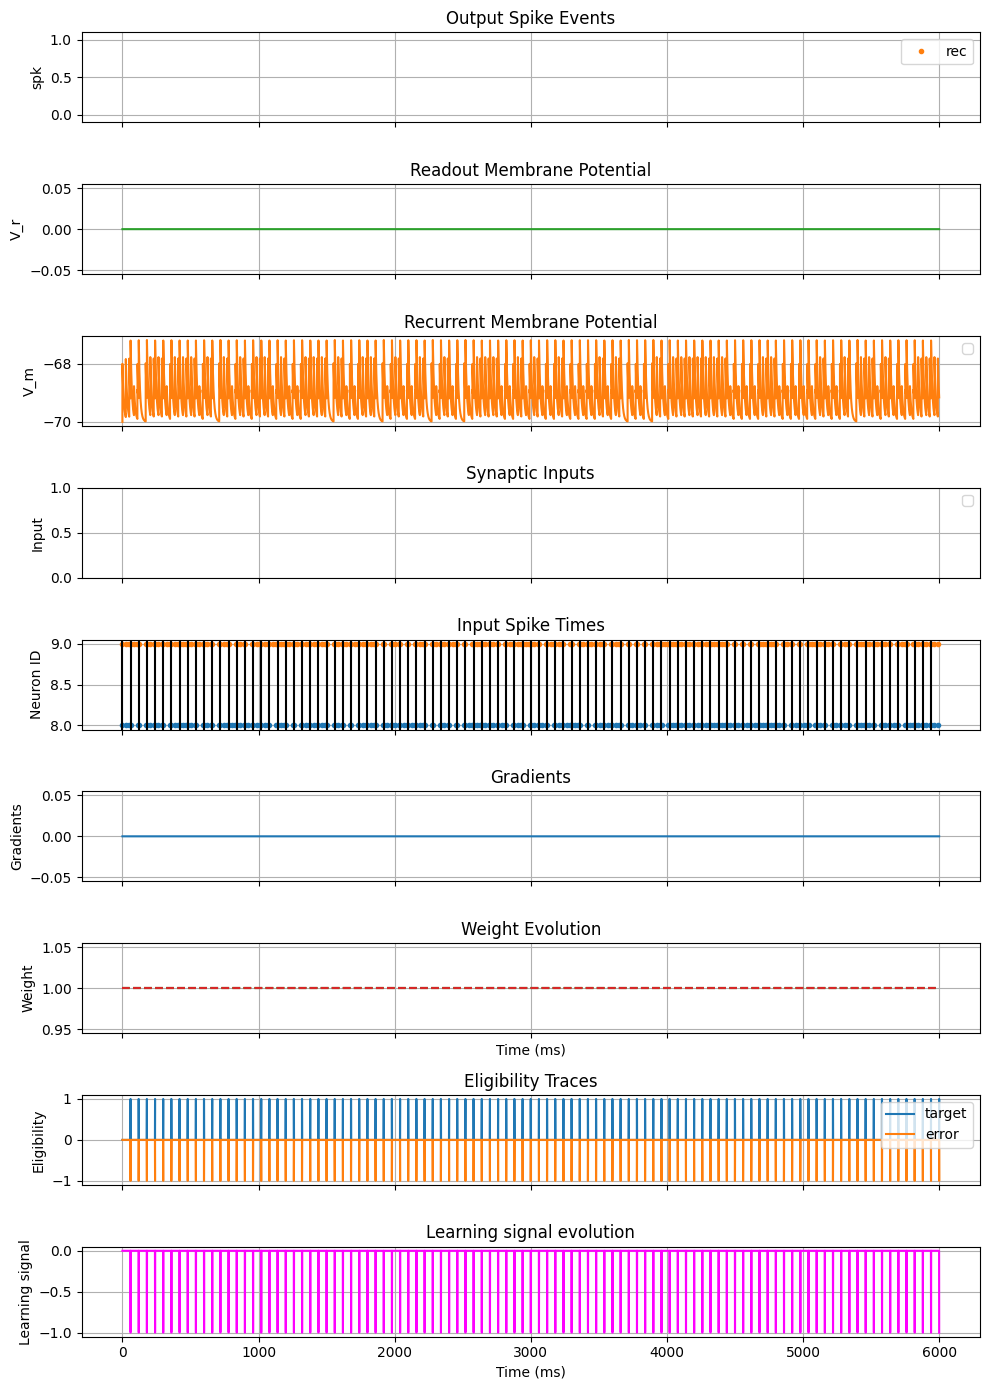

In [16]:
# %% ###########################################################################################################
rows = 9
fig, axs = plt.subplots(rows, 1, figsize=(10, 14), sharex=True)

# Plot 1: Output spikes as event markers (top panel)
axs[0].plot(ts_sr_rec, np.ones_like(ts_sr_rec) - 1, ".", color="C1", label=f"rec")
axs[0].set_ylabel("spk")
axs[0].set_title("Output Spike Events")
axs[0].set_ylim(-0.1, 1.1)
axs[0].legend(loc="upper right")
axs[0].grid()

# Readout Membrane Potential
axs[1].plot(ts_mm_out, Vrs, color="C2")
axs[1].set_ylabel("V_r")
axs[1].set_title("Readout Membrane Potential")
axs[1].grid()

# Plot 2: Somatic Membrane Potential
axs[2].plot(times_rec, Vms, color="C1")
axs[2].set_ylabel("V_m")
axs[2].set_title("Recurrent Membrane Potential")
axs[2].legend(loc="upper right")
axs[2].grid()

# 5. Inputs
#axs[3].plot(times_rec, d_inputs, label="dend_input")
#axs[3].plot(times_rec, s_inputs, label="soma_input")
axs[3].set_ylabel("Input")
axs[3].set_title("Synaptic Inputs")
axs[3].legend(loc="upper right")
axs[3].grid()

# 6. Input spike times
for sender in np.unique(df_in.index):
    spk_times = df_in.loc[sender]
    axs[4].plot(spk_times, np.ones_like(spk_times) * sender, ".")
for epoch in range(epochs):
    axs[4].axvline(x=epoch * iteration_steps * params_setup["resolution"], color="k")
axs[4].set_ylabel("Neuron ID")
axs[4].set_title("Input Spike Times")
axs[4].grid()


axs[5].plot(times_rec, surrogate_gradient)
#axs[5].plot(epochs_time, np.repeat(grads_d, iteration_steps, axis=0), label="g_dend", color="C0")
#axs[5].plot(epochs_time, np.repeat(grads_s, iteration_steps, axis=0), label="g_soma", color="C1")
#axs[5].plot(epochs_time, np.repeat(grads_r, iteration_steps, axis=0), label="g_r", color="C2")
axs[5].set_ylabel("Gradients")
axs[5].set_title("Gradients")
axs[5].grid()

# 8. Weight evolution
plot_weight_time_course(df_in_rec, axs[6])
plot_weight_time_course(df_rec_rec, axs[6])
plot_weight_time_course(df_rec_out, axs[6])
#axs[6].plot(epochs_time, np.repeat(W_dends, iteration_steps, axis=0), label=f"W_dend {W_dends[0][0]:.2f} {W_dends[-1][-1]:.2f}", color="C0")
#axs[6].plot(epochs_time, np.repeat(W_somas, iteration_steps, axis=0), label=f"W_soma {W_somas[0][0]:.2f} {W_somas[-1][-1]:.2f}", color="C1")
#axs[6].plot(epochs_time, np.repeat(W_os, iteration_steps, axis=0), label=f"W_out {W_os[0]:.2f} {W_os[-1]:.2f}", color="C2")
axs[6].set_ylabel("Weight")
axs[6].set_title("Weight Evolution")
axs[6].set_xlabel("Time (ms)")
axs[6].grid()

# 7. target and error (step-wise)
#axs[5].plot(epochs_time, np.concatenate(E_dends), label="E_dend", color="C0")
#axs[5].plot(epochs_time, np.concatenate(E_somas), label="E_soma", color="C1")
#axs[5].plot(epochs_time, np.concatenate(E_readouts), label="E_readout", color="C2")
axs[7].plot(ts_mm_out, target_signal, label="target")
axs[7].plot(ts_mm_out, error_signal, label="error")
axs[7].set_ylabel("Eligibility")
axs[7].set_title("Eligibility Traces")
axs[7].legend(loc="upper right")
axs[7].grid()

#axs[8].plot(epochs_time, np.repeat(Ls, iteration_steps), label=r"$\hat{y} - y$", color="magenta")
axs[8].plot(times_rec, learning_signal, color="magenta")
axs[8].set_ylabel("Learning signal")
axs[8].set_title("Learning signal evolution")
axs[8].set_xlabel("Time (ms)")
#axs[8].legend(loc="upper right")
axs[8].grid()

plt.tight_layout()
plt.show()

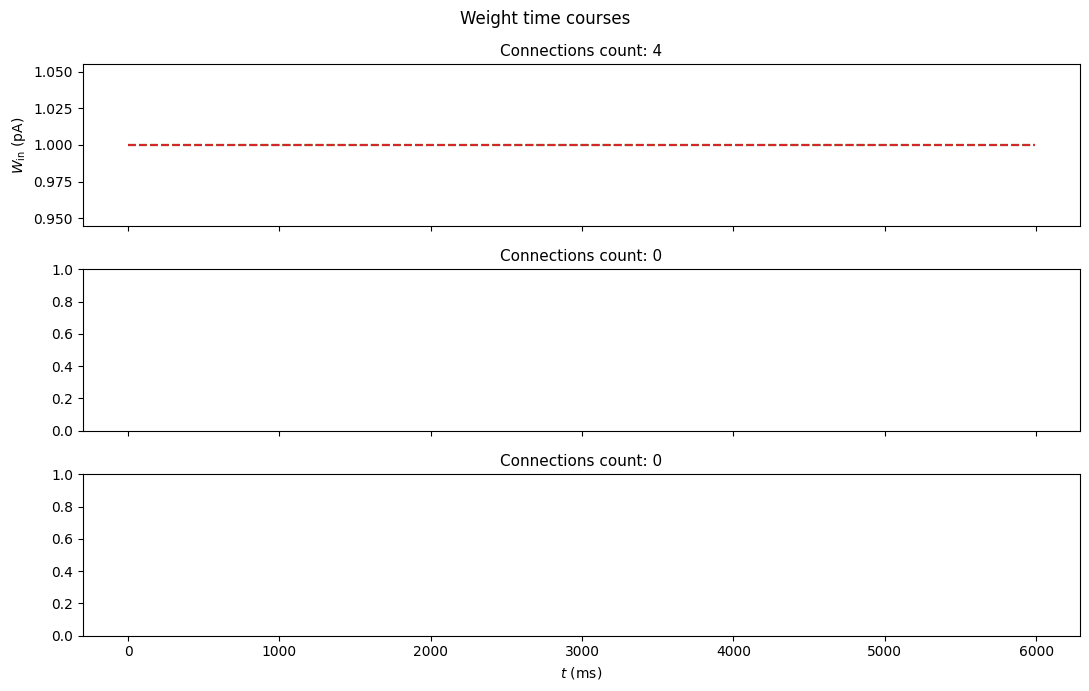

In [17]:
import pandas as pd

nrns = {
    "in": net.nrns_in.tolist(),
    "rec": net.nrns_rec.tolist(),
    "out": net.nrns_out.tolist(),
}

df_wr = pd.DataFrame(events_wr)
df_wr.set_index(["senders", "targets"], inplace=True)

in_rec_idx = pd.MultiIndex.from_product([nrns["in"], nrns["rec"]])
rec_rec_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["rec"]])
rec_out_idx = pd.MultiIndex.from_product([nrns["rec"], nrns["out"]])

df_in_rec = df_wr.loc[df_wr.index.intersection(in_rec_idx)]
df_rec_rec = df_wr.loc[df_wr.index.intersection(rec_rec_idx)]
df_rec_out = df_wr.loc[df_wr.index.intersection(rec_out_idx)]

def plot_weight_time_course(df, ax, ylabel):
    for idx in df.index.unique():
        df_filt = df.loc[idx]#.sort_values(by="time_ms")
        ax.plot(df_filt["times"], df_filt["weights"], "--")
        ax.set_ylabel(ylabel)
    ax.set_title(f"Connections count: {len(df.index.unique())}", fontsize=11)

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(11, 7))
fig.suptitle("Weight time courses")

plot_weight_time_course(df_in_rec, axs[0], r"$W_\text{in}$ (pA)")
plot_weight_time_course(df_rec_rec, axs[1], r"$W_\text{rec}$ (pA)")
plot_weight_time_course(df_rec_out, axs[2], r"$W_\text{out}$ (pA)")

axs[-1].set_xlabel(r"$t$ (ms)")
fig.align_ylabels()
fig.tight_layout()

plt.show()